In [1]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from qmhub.units import AMBER_HARTREE_TO_KCAL, AMBER_BOHR_TO_A
!pwd

/scratch/van/cas9/hnh/b3lyp-pm3-sinr2/ene_decomp


In [2]:
methods = ['b3lyp_6-31gd',
           'b3lyp_6-31+gd']#,
           # 'blyp_6-31gd',
           # 'blyp_6-31+gd',
           # 'wb97xd_6-31gd',
           # 'wb97xd_6-31+gd']

In [3]:
for method in methods:
    for window in range(42):
        fnames = sorted(glob('../%02d/%s_forces/*/qmmm_%s_energy.npy' % (window, method, method)))
        energy = []
        for fname in fnames:
            f = np.load(fname)
            energy.append(f)
        energies = np.concatenate(energy)
        np.save('../%02d/qmmm_%s_energy_all.npy' % (window,method), energies)

In [4]:
"""
Combine all windows to one file  in mbar folder
"""

n_windows = 42

enes = ['qmmm_b3lyp_6-31gd_energy',
        'qmmm_b3lyp_6-31+gd_energy',
        'qmmm_wb97xd_6-31gd_energy',
        'qmmm_wb97xd_6-31+gd_energy', 
        'qmmm_blyp_6-31gd_energy',
        'qmmm_blyp_6-31+gd_energy']

for ene in enes:
    fname = sorted(glob('../??/%s_all.npy' % (ene)))
    arr = [np.load(f)[::] for f in fname[:]]
    energies = np.column_stack(arr)
    np.save("../mbar/tp_energy/%s.npy" % ene, np.swapaxes(energies, 0, 1))

In [ ]:
reactant = ! ls -d ../00/*forces
reactant


for i in reactant:
    fnames = sorted(glob('%s/*/qmmm_*_energy.npy' % i))

    energy = []

    for fname in fnames:
        f = np.load(fname)
        energy.append(f)

    energies = np.concatenate(energy)
    window = i.split('/')[1]
    name = i.split('/')[2]
    # print(name)
    np.save('../%s/qmmm_%s-window%s.npy' % (window, name, window), energies)

In [48]:
ts = ! ls -d ../22/*forces

for i in ts:
    fnames = sorted(glob('%s/*/qmmm_*_energy.npy' % i))

    energy = []

    for fname in fnames:
        f = np.load(fname)
        energy.append(f)

    energies = np.concatenate(energy)
    window = i.split('/')[1]
    name = i.split('/')[2]
    # print(name)
    np.save('../%s/qmmm_%s-window%s.npy' % (window, name, window), energies)

In [64]:
ref_re = np.load('../00/qmmm_b3lyp_6-31gd_forces-window00.npy') * 27.114
ref_re_e = (ref_re - ref_re.mean()) * 23.061
ref_ts = np.load('../22/qmmm_b3lyp_6-31gd_forces-window22.npy') * 27.114
ref_ts_e = (ref_ts - ref_ts.mean()) * 23.061
ref_diff = ref_ts_e - ref_re_e

npys = sorted(glob('../00/qmmm*forces*window*npy'))
names = []
for i in npys:
    npy = i.split('/')[2]
    name = npy.split('window')[0]
    names.append(name)
    
print(names)
for j in range(len(name)):
    print(j)
    re = np.load('../00/%swindow00.npy' % names[j]) * 27.114
    re_e = (re - re.mean()) * 23.061
    ts = np.load('../22/%swindow22.npy' % names[j]) * 27.114
    ts_e = (ts - ts.mean()) * 23.061
    print(re_e.shape, ts_e.shape)
    diff = ts_e - re_e
    plt.scatter(ref_diff, diff)
    plt.show()

['qmmm_b3lyp_6-31+gd_forces-', 'qmmm_b3lyp_6-31gd_forces-', 'qmmm_blyp_6-31+gd_forces-', 'qmmm_blyp_6-31gd_forces-', 'qmmm_wb97xd_6-31+gd_forces-', 'qmmm_wb97xd_6-31gd_forces-']
0
(249, 1) (250, 1)


ValueError: operands could not be broadcast together with shapes (250,1) (249,1) 

In [118]:
ref = np.array(np.load('../mbar/qmmm_b3lyp_energy-test00-248.npy')[0] - np.load('../mbar/qmmm_b3lyp_energy-test00-248.npy')[21]) * 27.114
ref_e = (ref - ref.mean()) * 23.061

npys = sorted(glob('../mbar/qmmm*energy*248.npy'))
names = []
for i in npys:
    npy = i.split('/')[2]
    # name = npy.split('window')[0]
    names.append(npy)

# axis = 'E$_{TS}$ - E$_R$'
axis = str('$\Delta$E (kcal/mol)')
labels =['B3LYP/6-31G*', 'BLYP/6-31G*', 'wB97XD/6-31+G*', 'wB97XD/6-31G*']

print(names)
for j in range(len(name)):
    print(j)
    m = np.array(np.load('../mbar/%s' % names[j])[0] - np.load('../mbar/%s' % names[j])[21]) * 27.114
    m_e = (m - m.mean()) * 23.061
    plt.scatter(ref_e, m_e)
    plt.xlabel('Ref %s %s' % (labels[0], axis), fontsize=14)
    plt.ylabel('TP %s %s' % (labels[j], axis), fontsize=14)
    plt.xlim(-70,70)
    plt.ylim(-70,70)
    plt.plot([-80,80], [-80,80], color="k", linewidth=1)
    # plt.text(-60,60, 'RMSD: %.5f' % np.sqrt(np.mean(m_e - ref_e)**2), size=14)
    plt.savefig('deltaE%s.png' % j, dpi=300)
    plt.close()

['qmmm_b3lyp_energy-test00-248.npy', 'qmmm_blyp_6-31gd_energy-248.npy', 'qmmm_wb97xd_631+gd_energy-248.npy', 'qmmm_wb97xd_energy-test00-248.npy']
0
1
2
3
4


IndexError: list index out of range

['qmmm_b3lyp_6-31+gd_energy.npy', 'qmmm_blyp_6-31+gd_energy.npy', 'qmmm_blyp_6-31gd_energy.npy', 'qmmm_wb97xd_631+gd_energy.npy', 'qmmm_wb97xd_energy.npy']
0
(249, 1) (249, 1)
(250, 1) (249, 1)


ValueError: x and y must be the same size

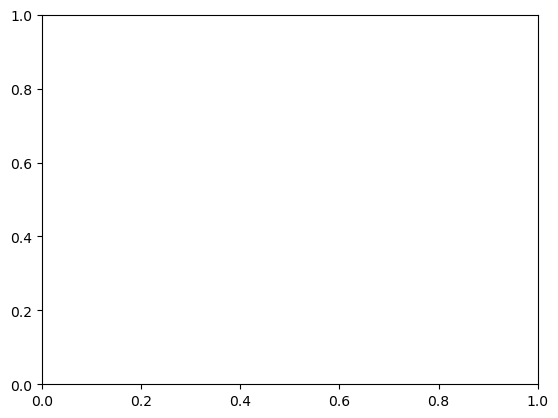

In [68]:
ref_re = np.load('../00/qmmm_b3lyp_energy-test00.npy') * 27.114
ref_re_e = (ref_re - ref_re.mean()) * 23.061
ref_ts = np.load('../22/qmmm_b3lyp_energy-test00.npy') * 27.114
ref_ts_e = (ref_ts - ref_ts.mean()) * 23.061
ref_diff = ref_ts_e - ref_re_e

npys = sorted(glob('../00/qmmm*energy.npy'))
names = []
for i in npys:
    npy = i.split('/')[2]
    # name = npy.split('window')[0]
    names.append(npy)
    
print(names)
for j in range(len(name)):
    print(j)
    re = np.load('../00/%s' % names[j]) * 27.114
    re_e = (re - re.mean()) * 23.061
    ts = np.load('../22/%s' % names[j]) * 27.114
    ts_e = (ts - ts.mean()) * 23.061
    print(re_e.shape, ts_e.shape)
    diff = ts_e - re_e
    print(ref_diff.shape, diff.shape)
    plt.scatter(ref_diff, diff)
    plt.show()

In [ ]:


ref = np.load('../00/qmmm_b3lyp_6-31+gd_energy.npy') * 27.2114
ref_energy = (ref - ref.mean()) * 23.061

fig, axs = plt.subplots(3,2, figsize=(7,8))

for fname, ax in zip(fnames, axs.ravel()):
    print(fname)
    f = np.load(fname) * 27.2114
    f_energy = (f - f.mean()) * 23.061
    method = fname.split('_')[1].upper()
    basis = fname.split('_')[2].replace('d', '*').replace('p', '*')
    ax.plot([-150,50],[-150,50])
    ax.scatter(ref_energy, f_energy, marker='*')
    ax.set_xlabel('Ref QM Energy (kcal/mol)', fontsize=10)
    ax.set_ylabel('Pred. QM Energy (kcal/mol)', fontsize=10)
    ax.set_title('%s/%s' % (method.upper(), basis.upper()), fontsize=12)
    ax.set_xlim(-150, 60)
    ax.set_ylim(-150, 60)
    ax.text(-140, 35, 'RMSD: %.3f' % np.sqrt(np.mean((ref_energy - f_energy)**2)), size=10)

plt.tight_layout()
# plt.savefig('qmmm_energies_scatter.png', dpi=300)